# Kunci Jawaban - Linear Regression

- **Dataset:** Auto MPG
- **Target:** `mpg`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Auto MPG menggunakan ID dataset dari UCI.

In [5]:
auto_mpg = fetch_ucirepo(id=9)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [6]:
X_raw = auto_mpg.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [7]:
y_raw = auto_mpg.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [8]:
TARGET_COL = "mpg"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df` agar mudah dicek di tahap EDA.

In [9]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [10]:
df.shape

(398, 8)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **398 baris** dan **8 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset memiliki **7 fitur** dan **1 target**, yaitu `mpg`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [11]:
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.000,8,130.000,3504,12.000,70,1,18.000
1,350.000,8,165.000,3693,11.500,70,1,15.000
2,318.000,8,150.000,3436,11.000,70,1,18.000
3,304.000,8,150.000,3433,12.000,70,1,16.000
4,302.000,8,140.000,3449,10.500,70,1,17.000


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya, semua kolom yang digunakan berisi angka.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Tidak, dataset tidak membutuhkan encoding kategori karena seluruh kolom yang digunakan berupa data numerik.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Tipe data kolom terdiri dari **4 kolom float64** dan **4 kolom int64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Ya, kolom `horsepower` memiliki jumlah non-null lebih sedikit daripada jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [13]:
df.isna().sum()

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Kolom `horsepower` memiliki **6 missing value**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Data perlu ditangani. Pada notebook ini, baris missing dihapus karena jumlahnya kecil dibanding total data.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [14]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah **0**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Tidak ada baris duplikat yang perlu dihapus.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [15]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000,398.000,392.000,398.000,398.000,398.000,398.000,398.000
mean,193.426,5.455,104.469,2970.425,15.568,76.010,1.573,23.515
std,104.270,1.701,38.491,846.842,2.758,3.698,0.802,7.816
min,68.000,3.000,46.000,1613.000,8.000,70.000,1.000,9.000
25%,104.250,4.000,75.000,2223.750,13.825,73.000,1.000,17.500
50%,148.500,4.000,93.500,2803.500,15.500,76.000,1.000,23.000
75%,262.000,8.000,126.000,3608.000,17.175,79.000,2.000,29.000
max,455.000,8.000,230.000,5140.000,24.800,82.000,3.000,46.600


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, `weight` bernilai ribuan, sedangkan `cylinders`, `origin`, dan `model_year` jauh lebih kecil.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus baris missing value

Hapus baris yang memiliki missing value agar dataset siap dipakai modeling sederhana.

In [16]:
df_clean = df.dropna().copy()

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [17]:
df_clean = df_clean.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah cleaning.

In [18]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah cleaning.

In [19]:
df_clean.shape

(392, 8)

> Berdasarkan output, berapa ukuran dataset setelah cleaning?

Jawaban: Setelah cleaning, dataset memiliki **392 baris** dan **8 kolom**.

> Berapa jumlah baris yang berkurang dari dataset awal?

Jawaban: Jumlah baris berkurang **6 baris** karena missing value pada `horsepower` dihapus.

### Cek ulang missing value

Pastikan tidak ada missing value yang tersisa.

In [20]:
df_clean.isna().sum()

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

> Berdasarkan output, apakah masih ada missing value setelah cleaning?

Jawaban: Tidak, semua kolom memiliki missing value **0** setelah cleaning.

> Jelaskan kondisi dataset setelah missing value ditangani.

Jawaban: Dataset sudah tidak memiliki missing value dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [21]:
df_clean[TARGET_COL].describe()

count   392.000
mean     23.446
std       7.805
min       9.000
25%      17.000
50%      22.750
75%      29.000
max      46.600
Name: mpg, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **23.45**, nilai minimum **9.00**, dan nilai maksimum **46.60**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Rentang nilai MPG cukup lebar, sehingga efisiensi bahan bakar mobil pada dataset cukup bervariasi.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

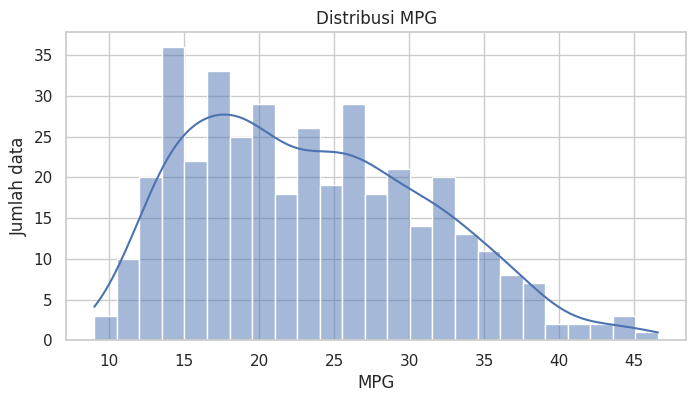

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=25, kde=True)
plt.title("Distribusi MPG")
plt.xlabel("MPG")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai MPG banyak muncul pada rentang sekitar **15 sampai 30**.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusi tidak sepenuhnya berbentuk lonceng sempurna dan masih menyebar ke nilai MPG yang lebih tinggi.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [23]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

model_year      0.581
origin          0.565
acceleration    0.423
cylinders      -0.778
horsepower     -0.778
displacement   -0.805
weight         -0.832
Name: mpg, dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `model_year`, `origin`, dan `acceleration` memiliki korelasi positif terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `weight`, `displacement`, `horsepower`, dan `cylinders` memiliki korelasi negatif terhadap target. Korelasi negatif paling besar terlihat pada `weight`.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

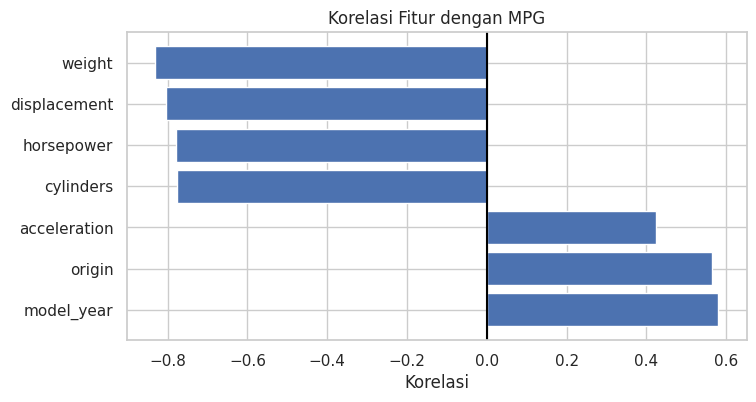

In [24]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan MPG")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi `model_year`, `origin`, dan `acceleration`. Sisi negatif berisi `cylinders`, `horsepower`, `displacement`, dan `weight`.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama MPG, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika MPG menurun.

### Buat scatter plot Weight dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `weight` dengan target.

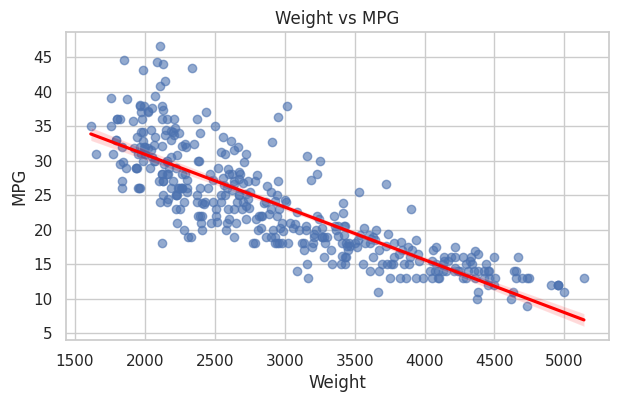

In [25]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="weight",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `weight` dengan target?

Jawaban: Mobil yang lebih berat cenderung memiliki MPG yang lebih rendah.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **negatif**.

### Buat line plot rata-rata MPG berdasarkan model year

Gunakan line plot rata-rata karena `model_year` adalah fitur waktu yang berurutan.

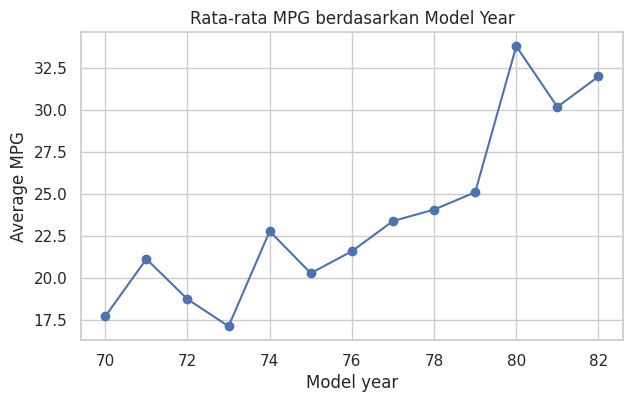

In [26]:
year_mean = df_clean.groupby("model_year")[TARGET_COL].mean()

plt.figure(figsize=(7, 4))
plt.plot(year_mean.index, year_mean.values, marker="o")
plt.title("Rata-rata MPG berdasarkan Model Year")
plt.xlabel("Model year")
plt.ylabel("Average MPG")
plt.show()

> Berdasarkan line plot, bagaimana perubahan rata-rata MPG dari tahun ke tahun?

Jawaban: Rata-rata MPG cenderung meningkat pada model year yang lebih baru.

> Mengapa line plot lebih tepat untuk `model_year`?

Jawaban: Line plot lebih tepat karena `model_year` adalah nilai waktu berurutan, sehingga perubahan rata-rata dari tahun ke tahun lebih mudah dibaca.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [27]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [28]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [29]:
X.shape

(392, 7)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **392 baris** dan **7 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [30]:
y.shape

(392,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **392 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **392**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [31]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [33]:
X_train.shape

(313, 7)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [34]:
X_test.shape

(79, 7)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **313 baris**, sedangkan data test memiliki **79 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **7 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [35]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [37]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [38]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [39]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [40]:
model.intercept_

np.float64(23.599361022364224)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **23.60**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [41]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
5,model_year,2.783
0,displacement,1.565
6,origin,1.300
4,acceleration,0.107
1,cylinders,-0.587
2,horsepower,-0.814
3,weight,-5.158


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `model_year` sekitar **2.78**, sedangkan koefisien negatif terbesar adalah `weight` sekitar **-5.16**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [42]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [43]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [44]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,26.000,25.842
1,21.600,26.037
2,36.100,34.506
3,26.000,24.896
4,27.000,28.426


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-1, dengan aktual **26.00** dan prediksi **25.84**. Prediksi paling jauh terlihat pada baris ke-2, dengan aktual **21.60** dan prediksi **26.04**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat dengan nilai aktual, tetapi masih ada prediksi dengan selisih beberapa MPG.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [45]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

2.5481681962151366

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [46]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

2.4197802491974527

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **2.42 MPG**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **2.42 MPG** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [47]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(3.3134960151437447)

### Hitung RMSE test

Hitung RMSE pada data test.

In [48]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(3.2727457003009555)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **3.27 MPG**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [49]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.826001578671067

### Hitung R2 test

Hitung R2 Score pada data test.

In [50]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.7901500386760346

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.79**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **79%** variasi MPG pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [51]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,2.548,3.313,0.826
1,Test,2.420,3.273,0.790


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih kecil daripada MAE train, RMSE test sedikit lebih kecil daripada RMSE train, dan R2 test lebih kecil daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **5.04%** lebih kecil, RMSE test sekitar **1.23%** lebih kecil, dan R2 test sekitar **4.34%** lebih kecil dibanding train. Performa train dan test masih cukup seimbang.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

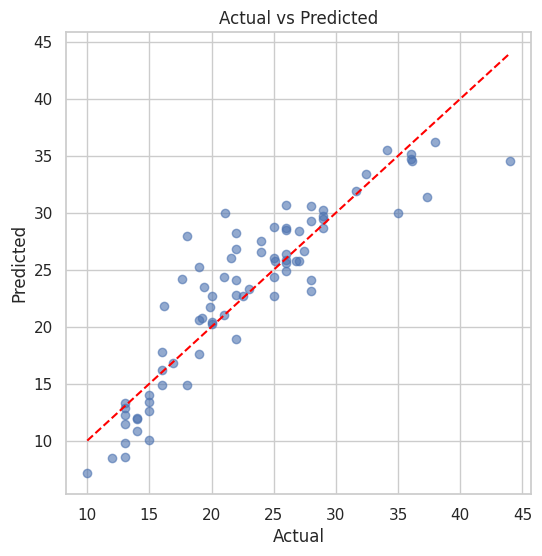

In [52]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Auto MPG digunakan untuk memprediksi `mpg` berdasarkan spesifikasi kendaraan. Data memiliki missing value pada kolom `horsepower` dan tidak memiliki baris duplikat penuh. Setelah cleaning, dataset memiliki **392** baris dan **8** kolom.

Hasil EDA menunjukkan bahwa `model_year`, `origin`, dan `acceleration` memiliki hubungan positif dengan target, sedangkan `weight`, `displacement`, dan `horsepower` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **2.42 MPG**, RMSE test sekitar **3.27 MPG**, dan R2 test sekitar **0.79**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **79%** variasi target pada data test dengan rata-rata error absolut sekitar **2.42 MPG**.